# Week 5

Yay! It's week 5. One Assignment down. Look at how far you've already come. 

## Today

But there's an entire aspect of the data that we haven't used much. The geospatial aspect. That's basically all we'll be doing today. This lecture covers:

1. **Choropleth maps with Plotly**: You'll learn to visualize SF police districts using color-coded shapefiles, starting from random data and building up to real crime statistics.
2. **Interactive maps with Folium**: A second mapping library — you'll create point scatter maps, heatmaps, and an animated "movie" showing how crime patterns shift over time.
3. **Putting it all together**: An open-ended spatio-temporal analysis where you apply the full toolkit you've built over the past weeks to understand a single crime type in depth.

## Part 1: Visualizing geodata with Plotly

So visualizing geodata used to be difficult, but with `Plotly` things have gotten easier. 

Like matplotlib, Plotly is an [open-source data visualization library](https://plotly.com/python/), but it's aimed at making interactive visualizations that can be rendered in a web browser (or jupyter notebook). You can read about it and learn how to install it [here](https://plotly.com/python/getting-started/).

That means that we can easily draw on the fact that the crime data has lots of exciting geo-data attached. The map we're going to be creating is called a **[choropleth map](https://en.wikipedia.org/wiki/Choropleth_map)** (more on these later), which is basically a map, where we color in shapefiles (more on this below) based on some value that we care about. We'll take our inspiration from Plotly's gentle intro to [Choropleth maps](https://plotly.com/python/mapbox-county-choropleth/)

Back in Week 3, you computed `P(crime|district)/P(crime)` ratios to compare crime profiles across SF's police districts. You had numbers — but numbers alone can't reveal the geographic patterns hidden across the 10 districts. This week, we'll take that analysis one step further: instead of just reading off ratios, we'll put those patterns directly on a map.

The thing we want to look into is the SF police districts, shown below (image stolen from [this page](https://hoodline.com/2015/07/citywide-sfpd-redistricting-to-take-effect-sunday/)).

![districts from web](https://raw.githubusercontent.com/suneman/socialdata2021/master/files/sfpdfinal.png)

But because we are cool programmers, we want to create our own maps, **with our own information on them**. Let's do it!

> *Exercise 1.1*: Let's plot a map with some random values in it. <font color="gray"></font>

<div class="alert alert-block alert-info">
For this exercise, it will be tempting to ask your LLM for a lot of help ... but - again - don't let it do the work for you. Use it as a helper - not an end-to-end solution. There are many new concepts to understand, and doing the exercise yourself is the best way to begin to get the nitty-gritty details of maps and shapefiles under your skin. Once you get the idea of shapefiles and how they work into your human head, it will unlock new & powerful ways of thinking.
</div>

> What we need to do to get going is some random data. Below is a little dictionary with a random value for each district.

In [2]:
randomdata = {
    'CENTRAL': 0.4821,
    'SOUTHERN': 0.9153,
    'BAYVIEW': 0.3674,
    'MISSION': 0.7542,
    'PARK': 0.6285,
    'RICHMOND': 0.2147,
    'INGLESIDE': 0.05391,
    'TARAVAL': 0.007846,
    'NORTHERN': 0.4938,
    'TENDERLOIN': 0.08127
}

> *Exercise 1.1* (continued):
>
> For this exercise, we'll use the random values above and we'll also need some *shape-files*.
> [Shapefiles can have many different formats](https://en.wikipedia.org/wiki/Shapefile). Because we are brilliant teachers and an all-round standup people, we are sharing the shapefiles as [`geojson`](https://en.wikipedia.org/wiki/GeoJSON), which is an easy-to-use format for shapefiles based on `json`.
>
> * Download the SFPD District shapefiles **[here](https://raw.githubusercontent.com/suneman/socialdata2025/main/files/sfpd.geojson)**
> * Now that you have the shapefiles, you can follow the example here: https://plotly.com/python/mapbox-county-choropleth/ but with the following modifications:
>    * In the example the `id` is a so-called FIPS code. In our case the `id` is the `DISTRICT`
>    * You will have to convert the dictionary of random values I included above to a Pandas dataframe with the right column headings.
>    * The data used in the example has a range between zero and 12. Your data is between $[0,1]$. So you'll need to modify the plotting command to accound for that change.
>    * You should also change the map to display the right zoom level.
>    * And the map should center on San Francisco's `lat` and `lon`.
> * Now you can create your map.

Mine looks something like this (but I've changed the random values to make it more fun, so expect your colors to be different.).



<img src="https://raw.githubusercontent.com/suneman/socialdata2025/main/files/map_example.png" alt="example" style="width:800px;"/>

You're encouraged to play around with other settings, color schemes, etc.

In [22]:
# Step 1.1: Choropleth map with random district values

import json
import pandas as pd
import plotly.express as px
import plotly.io as pio

# render map in browser
pio.renderers.default = "browser"

# random data
randomdata = {
    'CENTRAL': 0.4821,
    'SOUTHERN': 0.9153,
    'BAYVIEW': 0.3674,
    'MISSION': 0.7542,
    'PARK': 0.6285,
    'RICHMOND': 0.2147,
    'INGLESIDE': 0.05391,
    'TARAVAL': 0.007846,
    'NORTHERN': 0.4938,
    'TENDERLOIN': 0.08127
}

# convert dictionary to dataframe
df_random = pd.DataFrame(
    list(randomdata.items()),
    columns=["DISTRICT", "value"]
)

# load geojson shapefile
with open("../../dataset/Week5/sfpd.geojson") as f:
    geojson = json.load(f)

# create choropleth map
fig = px.choropleth_map(
    df_random,
    geojson=geojson,
    locations="DISTRICT",
    featureidkey="properties.DISTRICT",
    color="value",
    color_continuous_scale="Viridis",
    range_color=(0, 1),
    map_style="carto-positron",
    zoom=11,
    center={"lat": 37.7749, "lon": -122.4194},
    opacity=0.7
)

fig.update_layout(
    title="Random values across SF police districts",
    margin={"r":0, "t":40, "l":0, "b":0}
)

fig.show()

> *Exercise 1.2*: Now let's replace the random values with something real.
>
> You already computed `P(crime|district)/P(crime)` ratios in Week 3 — a measure of how much each district deviates from the city-wide average for a given crime type. Let's put one of those ratio sets on a map.
>
> * Pick one of your Personal Focus Crimes.
> * Compute `P(crime|district)/P(crime)` for each of the 10 SF police districts (just as you did in Week 3, Exercise 2.1).
> * Replace the `randomdata` dictionary with your computed ratios, using the same district names as keys.
> * Re-run your choropleth. Remember to update the color scale range to match your new data.
> * Comment on what you see. Does the geographic pattern match your intuition from Week 3? Is it easier to read the pattern on a map than in a bar chart? What's new/different?
>     * Hint 1: Remember the color bar! Without it we can't make sense of the data.
>     * Hint 2: Because the value 1 is special for ratios (it means "same as the city average"), it's meaningful to use a **diverging color scale** — e.g. increasingly red for values above 1 and increasingly blue for values below 1. That makes the map much easier to parse because the colors align with the "idea" of the underlying numbers.

<div class="alert alert-block alert-info">
It's OK to use your LLM to help with the data wrangling here. The interpretation should be your own.
</div>

In [5]:
# Step 1.2: Choropleth map with real crime ratios

import pandas as pd
import json
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "browser"

# load dataset
df = pd.read_csv("../../dataset/Week2/merged_police_incidents.csv")

# keep relevant columns
df = df[["Unified Category", "Police District"]].dropna()

# choose one focus crime
crime = "Drug Offense"

# P(crime)
p_crime = (df["Unified Category"] == crime).mean()

# P(crime | district)
p_cd = (
    df.groupby("Police District")["Unified Category"]
    .apply(lambda x: (x == crime).mean())
)

# ratio P(crime|district) / P(crime)
ratio = p_cd / p_crime

# convert to dataframe for plotly
df_ratio = ratio.reset_index()
df_ratio.columns = ["DISTRICT", "ratio"]

# load geojson
with open("../../dataset/Week5/sfpd.geojson") as f:
    geojson = json.load(f)

# choropleth map
fig = px.choropleth_map(
    df_ratio,
    geojson=geojson,
    locations="DISTRICT",
    featureidkey="properties.DISTRICT",
    color="ratio",
    color_continuous_scale="RdBu_r",
    range_color=(df_ratio["ratio"].min(), df_ratio["ratio"].max()),
    map_style="carto-positron",
    zoom=11,
    center={"lat": 37.7749, "lon": -122.4194},
    opacity=0.7
)

fig.update_layout(
    title=f"P({crime}|district) / P({crime}) across SF districts",
    margin={"r":0, "t":40, "l":0, "b":0},
    coloraxis_colorbar=dict(title="Ratio")
)

fig.show()

#### Step 1.2 Observations

##### Comment on what you see. Does the geographic pattern match your intuition from Week 3? Is it easier to read the pattern on a map than in a bar chart? What's new/different?

The map shows that Tenderloin has a much higher ratio for Drug Offense (deep red), meaning drug-related incidents are strongly over-represented there compared to the city average. Most other districts appear blue, indicating values below 1, meaning drug offenses occur there less often than the city-wide average.

This geographic pattern matches what we observed in Week 3, where Tenderloin clearly stood out when examining the ratios numerically. However, the spatial visualization makes the pattern much easier to interpret because we can directly see where the concentration occurs in the city rather than only comparing bars.

The diverging color scale helps interpretation because the value 1 represents the city average: districts colored red (>1) are over-represented while blue (<1) indicates under-representation. The color bar is essential because it provides the numeric reference needed to interpret how strong the deviation from the average actually is.

> *Exercise 1.3:* But it's crime-data. Let's use the map for a genuinely new purpose.
> 
> * Now, we can focus on the following goal: *determine the districts where you should (and should not) leave your car on Sundays*. (Or stated differently, count up the number of thefts.)
> * To do so, first:
>  * Filter the crime dataset by the `DayOfWeek` category and also choose the appropriate crime category.
>  * Aggregate data by police district.
> * To create the plot, remember that your range of data-values is different from before, so you'll have to change the plotly command a bit.
> * Create a nice plot that shows the crime-levels and highlights the safest area. Remember that we want a colorbar to explain what the colors mean ... and all the other formatting needed for a nice plot.
> * Based on your map and analysis, where should you park the car for it to be safest on a Sunday? And where's the worst place?
> * Using visualizatios can help us uncover powerful data-patterns. However, when designing visualizations, we need to be aware of several illusions that can lead viewers to misinterpret the data we are showing (i.e. *perceptual errors*):
>    * Try to change the range of data-values in the plot above. Is there a way to make the difference between district less evident? 
>    * Why do you think perceptual errors are a problem? Try to think of a few examples. You can have a look at this [Snopes fact-check](https://www.snopes.com/fact-check/fox-news-obamacare-enrollment-chart/) to get some inspiration.
> * <font color="gray">Optional LLM challenge: Use your LLM and your existing code to easily create plots for the same crime type, but different days, and comment on the results.</font>

<div class="alert alert-block alert-info">
For this final exercise, go nuts with using your LLM (but this is only OK if you've already solved the previous one on your own).
</div>

In [6]:
# Step 1.3: Choropleth map for vehicle theft on Sundays

import pandas as pd
import json
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "browser"

# load dataset
df = pd.read_csv("../../dataset/Week2/merged_police_incidents.csv")

# keep relevant columns
df = df[["Unified Category", "Police District", "Incident Datetime"]].dropna()
df["Incident Datetime"] = pd.to_datetime(df["Incident Datetime"], errors="coerce")

# extract day of week
df["DayOfWeek"] = df["Incident Datetime"].dt.day_name()

# choose crime type
crime = "Vehicle Theft"

# filter Sundays and chosen crime
df_sunday = df[(df["DayOfWeek"] == "Sunday") & (df["Unified Category"] == crime)]

# aggregate counts by district
counts = df_sunday.groupby("Police District").size().reset_index(name="count")
counts.columns = ["DISTRICT", "count"]

# load geojson
with open("../../dataset/Week5/sfpd.geojson") as f:
    geojson = json.load(f)

# create choropleth map
fig = px.choropleth_map(
    counts,
    geojson=geojson,
    locations="DISTRICT",
    featureidkey="properties.DISTRICT",
    color="count",
    color_continuous_scale="YlOrRd",
    map_style="carto-positron",
    zoom=11,
    center={"lat": 37.7749, "lon": -122.4194},
    opacity=0.7
)

fig.update_layout(
    title=f"{crime} incidents on Sundays by district",
    margin={"r":0, "t":40, "l":0, "b":0},
    coloraxis_colorbar=dict(title="Incidents")
)

fig.show()

#### Step 1.3 Observations

##### Where should you park the car on Sundays?

Based on the map, the **Tenderloin district appears to have the lowest number of vehicle theft incidents on Sundays**, making it the safest district to leave a car among the ten police districts. In contrast, districts such as **Mission and Bayview** show the highest numbers of theft incidents, meaning they would be the riskiest places to park a car on Sundays.

Visualizing the data on a map makes the pattern easier to interpret compared to a bar chart. While a bar chart shows the counts clearly, the map reveals the **geographic distribution of theft risk across the city**, helping us see how high-risk and low-risk districts are spatially arranged.

##### Perceptual errors

Changing the color scale range can significantly alter how differences between districts appear. For example, if the range is widened too much, the districts may appear very similar even if the actual theft counts differ substantially. Conversely, narrowing the range can exaggerate small differences and make districts look more different than they really are.

Perceptual errors are problematic because visualizations strongly influence how viewers interpret data. Poor design choices such as misleading color scales, truncated axes, or distorted proportions can lead people to draw incorrect conclusions. For instance, charts that manipulate axis ranges can exaggerate trends or minimize differences, which can misrepresent the underlying data.

## Part 2: Visualizing geo-data with Folium

It turns out that `plotly` is not the only way of working with geo-data. There are many different ways to go about it. (The more advanced PhD and PostDoc researchers in my group simply use matplotlib, since that provides more control.)

Today, we'll try another library for geodata called [Folium](https://github.com/python-visualization/folium). It's good for you all to try out a few different libraries - remember that data visualization and analysis in Python is all about the ability to use many different tools. 

The exercise below is based on the code illustrated in this nice [tutorial](https://www.kaggle.com/daveianhickey/how-to-folium-for-maps-heatmaps-time-data), so let us start by taking a look at that one.

*Reading*. Read through the following tutorial
 * "How to: Folium for maps, heatmaps & time data". Get it here: https://www.kaggle.com/daveianhickey/how-to-folium-for-maps-heatmaps-time-data. \[**UPDATE 2026**: This is still a great tutorial, but the Stamen tile provider shut down in 2023, so any code using `tiles='Stamen Terrain'` or similar will fail. Use `tiles='OpenStreetMap'` instead (this is also Folium's default if you omit the `tiles` argument entirely). \]
 * <font color=gray>You can also experiment with getting your LLM to generate a nice tutorial for you, if you're so inclined.</font>

> *Exercise 2.1*: A different take on geospatial data.
>
> Earlier today in Part 1, we worked with spatial data by using color-intensity of shapefiles to show the counts of certain crimes across SF's police districts. Now, we look at a different approach: plotting raw data points and heatmaps on top of actual maps.
> 
> * First start by plotting a map of San Francisco with a nice tight zoom. Simply use the command `folium.Map([lat, lon], zoom_start=13)`, where `lat=37.7749` and `lon=-122.4194` (the center of SF).
> * Next, add a pop-up enabled marker for SF City Hall at coordinates `37.77919, -122.41914`.


![example](https://raw.githubusercontent.com/suneman/socialdata2025/main/files/simple_map.png)

<div class="alert alert-block alert-info">
Try to get the basic map working yourself first — it's a great way to get Folium's fundamentals under your skin. Feel free to ask your LLM if you get stuck on specific commands.
</div>

> * Now, let's plot some more data (no need for pop-ups this time). Select a couple of months of data for 'Drug Offense' (or another crime type from your Personal Focus Crimes if 'Drug Offense' is not on your list) and draw a little dot for each arrest for those two months. You could, for example, choose June-July 2016, but you can choose anything you like - the main concern is to not have too many points as this uses a lot of memory and makes Folium behave non-optimally. > We can call this kind of visualization a *point scatter plot*. <div class="alert alert-block alert-info"> It's OK to use LLMs for the folium exercises (this one and the next two). But do try to understand the code that you're putting together. </div>

In [1]:
# Step 2.1: Basic Folium map with markers and crime points

import pandas as pd
import folium

# load dataset
df = pd.read_csv("../../dataset/Week2/merged_police_incidents.csv")

# convert datetime
df["Incident Datetime"] = pd.to_datetime(df["Incident Datetime"], errors="coerce")

# keep relevant columns
df = df[["Incident Datetime", "Latitude", "Longitude", "Unified Category"]].dropna()

# filter for Drug Offense in June–July 2016
crime = "Drug Offense"
df_filtered = df[
    (df["Unified Category"] == crime) &
    (df["Incident Datetime"] >= "2016-06-01") &
    (df["Incident Datetime"] <= "2016-07-31")
]

# create base map centered on San Francisco
sf_map = folium.Map(location=[37.7749, -122.4194], zoom_start=13)

# add marker for SF City Hall
folium.Marker(
    location=[37.77919, -122.41914],
    popup="SF City Hall"
).add_to(sf_map)

# add points for each crime incident
for _, row in df_filtered.iterrows():
    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=2,
        color="red",
        fill=True,
        fill_opacity=0.6
    ).add_to(sf_map)

sf_map



Ok. Time for a little break. Note that a nice thing about Folium is that you can zoom in and out of the maps.

> *Exercise 2.2*: Heatmaps.
> * Now, let's play with **heatmaps**. You can figure out the appropriate commands by grabbing code from the main [tutorial](https://www.kaggle.com/daveianhickey/how-to-folium-for-maps-heatmaps-time-data)) and modifying to suit your needs.
>    * To create your first heatmap, grab all arrests for the category `'Prostitution'` (or another spatially interesting crime from your Personal Focus Crimes) across all time. Play with parameters to get plots you like.
>    * Now, comment on the differences between scatter plots and heatmaps. 
>      - What can you see using the scatter-plots that you can't see using the heatmaps? 
>      - And *vice versa*: what does the heatmaps help you see that's difficult to distinguish in the scatter-plots?
>    * Play around with the various parameters for heatmaps. You can find a list here: https://python-visualization.github.io/folium/plugins.html
>    * Comment on the effect on the various parameters for the heatmaps. How do they change the picture? (for example, try ,`radius=10` and `blur=5` - what happens to the image?).

In [4]:
# Step 2.2: Heatmap of Prostitution incidents

import pandas as pd
import folium
from folium.plugins import HeatMap

# load dataset
df = pd.read_csv("../../dataset/Week2/merged_police_incidents.csv")

# keep relevant columns and remove missing coordinates
df = df[["Unified Category", "Latitude", "Longitude"]].dropna()

# filter for Prostitution incidents
crime = "Prostitution"
df_heat = df[df["Unified Category"] == crime]

# create base map centered on San Francisco
heat_map = folium.Map(location=[37.7749, -122.4194], zoom_start=13)

# convert coordinates to list format for heatmap
heat_data = df_heat[["Latitude", "Longitude"]].values.tolist()

# add heatmap layer
HeatMap(
    heat_data,
    radius=20,
    blur=15,
    min_opacity=0.4
).add_to(heat_map)

heat_map

#### Step 2.2 Observations

##### Differences between scatter plots and heatmaps

Scatter plots display every individual crime incident as a point on the map, which makes it possible to see the **exact location of each event**. This can be useful for identifying precise locations or individual outliers. However, when many points are plotted, the map can become cluttered and it becomes difficult to identify overall spatial patterns.

Heatmaps instead aggregate nearby points and represent them through **color intensity**, highlighting areas with higher concentrations of incidents. This makes it easier to detect **crime hotspots and broader spatial patterns**, even when there are many overlapping data points.

Because of this, scatter plots are better for understanding **exact event locations**, while heatmaps are better for identifying **clusters and general spatial trends** across the city.

##### Effect of heatmap parameters

Changing parameters such as `radius` and `blur` affects how the heatmap represents the data. Increasing the `radius` spreads each point over a larger area, making hotspots appear broader and more continuous. Increasing the `blur` smooths the transitions between areas, which helps highlight general patterns but can also hide smaller local clusters. Adjusting these parameters changes how clearly hotspots appear and how detailed the spatial structure looks.

For the final element of working with heatmaps, let's now use the cool Folium functionality `HeatMapWithTime` to create a visualization of how the patterns of your favorite crime-type changes over time.

> *Exercise 2.3*: Heatmap movies. This exercise is a bit more independent than above - you get to make all the choices.
> * Start by choosing your favorite crime type from your Personal Focus Crimes. Preferably one with spatial patterns that change over time (use your data-exploration from the previous lectures to choose a good one).
> * Now, choose a time-resolution. You could plot daily, weekly, monthly datasets to plot in your movie. Again the goal is to find interesting temporal patterns to display. We want at least 20 frames though.
> * Create the movie using `HeatMapWithTime`.
> * Comment on your results: 
>   - What patterns does your movie reveal?
>   - Motivate/explain the reasoning behind your choice of crime type and time-resolution.

<div class="alert alert-block alert-info">
It's fine to use your LLM to help with the <code>HeatMapWithTime</code> code — the interpretation and the choices of crime type and time resolution should be your own.
</div>

In [7]:
# Step 2.3: Heatmap movie using HeatMapWithTime

import pandas as pd
import folium
from folium.plugins import HeatMapWithTime

# load dataset
df = pd.read_csv("../../dataset/Week2/merged_police_incidents.csv")

# convert datetime
df["Incident Datetime"] = pd.to_datetime(df["Incident Datetime"], errors="coerce")

# keep relevant columns
df = df[["Incident Datetime", "Latitude", "Longitude", "Unified Category"]].dropna()

# choose crime type
crime = "Vehicle Theft"
df_crime = df[df["Unified Category"] == crime].copy()

# create a monthly time resolution
df_crime["YearMonth"] = df_crime["Incident Datetime"].dt.to_period("M")

# group coordinates by month
time_groups = []
time_labels = []

for period, group in df_crime.groupby("YearMonth"):
    coords = group[["Latitude", "Longitude"]].values.tolist()
    if len(coords) > 0:
        time_groups.append(coords)
        time_labels.append(str(period))

# create base map
map_movie = folium.Map(location=[37.7749, -122.4194], zoom_start=12)

# add heatmap with time
HeatMapWithTime(
    time_groups,
    index=time_labels,
    radius=12,
    auto_play=False,
    max_opacity=0.8
).add_to(map_movie)

map_movie

#### Step 2.3 Observations

##### Patterns revealed by the heatmap movie
The heatmap movie shows that **vehicle theft incidents are not evenly distributed across San Francisco**, but instead form persistent hotspots in specific areas of the city. The densest activity appears in the **central and eastern parts of the city**, including areas around downtown and the Mission district. Over time, the intensity of these hotspots changes slightly, but the general locations remain relatively stable, indicating that some neighborhoods consistently experience higher levels of vehicle theft.

##### Choice of crime type and time resolution
Vehicle Theft was chosen because it is **one of the more common crimes in the dataset**, which ensures enough data points to create clear heatmap patterns. Crimes with very few observations would produce sparse or uninformative frames.  

A **monthly time resolution** was used because it provides a good balance between temporal detail and visual clarity. If the time resolution were too fine (e.g., daily), many frames would contain very few incidents and the heatmap would appear noisy. Monthly aggregation ensures that each frame contains enough incidents to clearly highlight spatial patterns while still allowing changes over time to be observed.

## Part 3: Putting everything you've learned to work

Now you've learned about lots of time-series analysis tricks and visualization. That means it's time for you to think for yourself with a slightly more independent exercise.

> *Exercise 3.1*: Using all the tools to understand the spatio-temporal patterns of a crime type.
> * I'd like you to present your own analysis of what happens to `'Prostitution'` in SF over time. If `'Prostitution'` is not part of your Personal Focus Crimes, choose another crime type with interesting spatio-temporal patterns.
>   - Hint 1: So think about trends over time, does every district show the same behavior?, or the same behavior over time?, are there hotspots?, etc. A fancy way of saying this is: think about quantifying and explaining spatio-temporal patterns.
>   - Hint 2: It's a good idea to think of this exercise as a way to show off what you've learned about data analysis in this and the previous lectures: so it's a good idea to include many of the types of plots from the curriculum so far in your analysis.
> * As an extra little thing, I also want you to reflect on the *role of data errors* in an analysis. Data errors could be things like imprecise GPS points, or imprecise recording of time.
> * Finally, think critically about what your analysis reveals. If law enforcement used your hotspot maps to deploy more officers to certain areas, how would that affect the crime data collected in future years? Does this create a feedback loop? How does this connect to the "dirty data" argument from the Richardson et al. reading in Week 1?

<div class="alert alert-block alert-info">
As almost always, it's OK to use LLMs to help you make your analysis better. But start by thinking about the data with your own human brain, start by coming up with what you want to know and which visualizations could help you understand things better. The thing I hope <b>does not happen</b> is that you use an LLM to come up with the ideas for you - or simply doing the analysis for you (because if that's your choice, you won't learn anything).
</div>

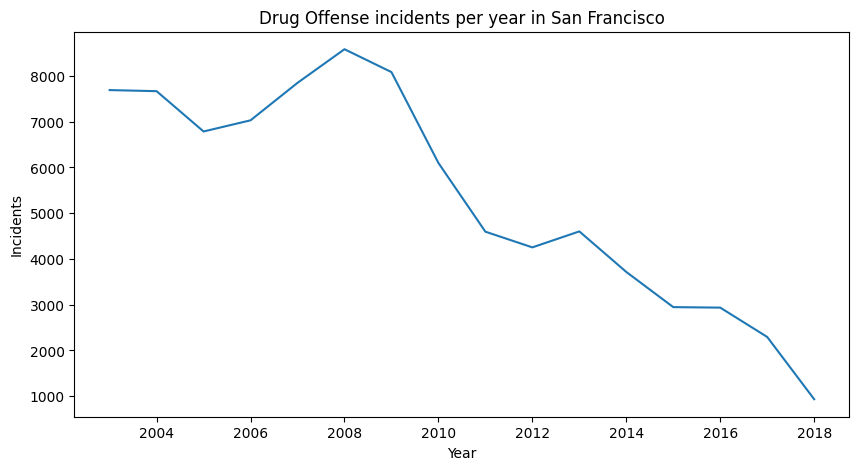

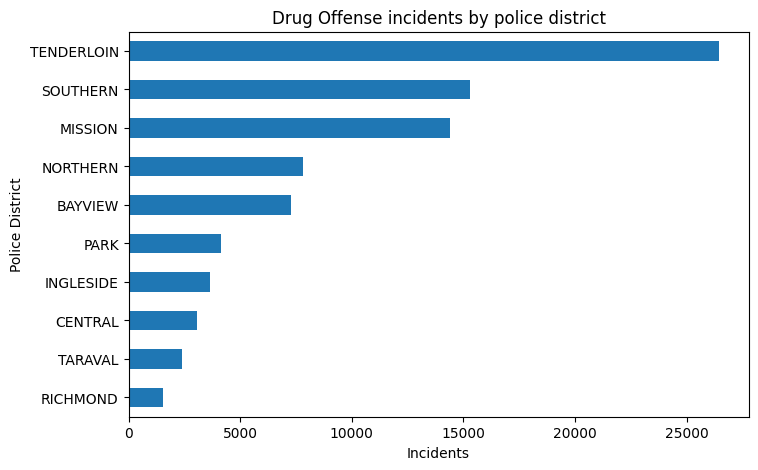

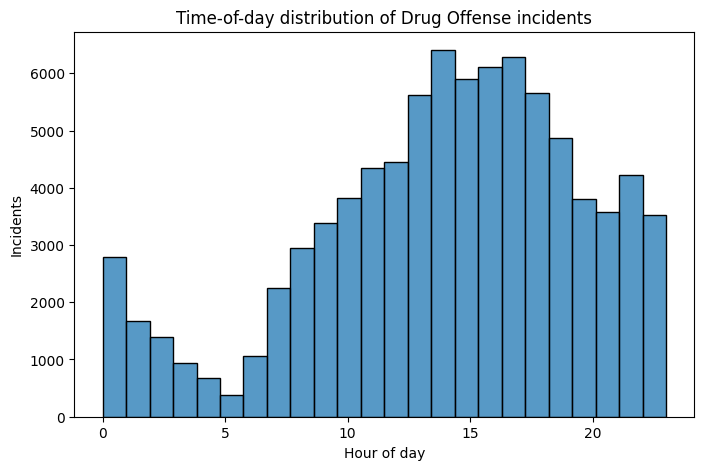

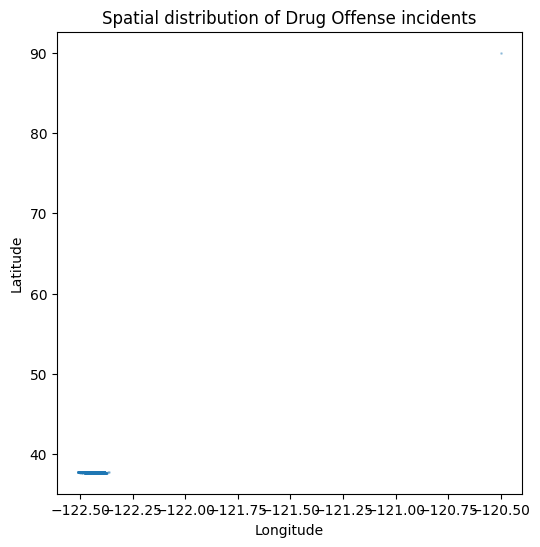

In [4]:
# Step 3.1: Spatio-temporal analysis of Drug Offense in San Francisco

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
df = pd.read_csv("../../dataset/Week2/merged_police_incidents.csv")

# convert datetime
df["Incident Datetime"] = pd.to_datetime(df["Incident Datetime"], errors="coerce")

# keep relevant columns
df = df[
    [
        "Incident Datetime",
        "Latitude",
        "Longitude",
        "Police District",
        "Unified Category"
    ]
].dropna()

# filter drug offense incidents
df_crime = df[df["Unified Category"] == "Drug Offense"].copy()

# create useful time variables
df_crime["Year"] = df_crime["Incident Datetime"].dt.year
df_crime["Hour"] = df_crime["Incident Datetime"].dt.hour


# Temporal trend (incidents per year)
year_counts = df_crime.groupby("Year").size()

plt.figure(figsize=(10,5))
year_counts.plot()
plt.xlabel("Year")
plt.ylabel("Incidents")
plt.title("Drug Offense incidents per year in San Francisco")
plt.show()


# District distribution
district_counts = df_crime.groupby("Police District").size().sort_values()

plt.figure(figsize=(8,5))
district_counts.plot(kind="barh")
plt.xlabel("Incidents")
plt.title("Drug Offense incidents by police district")
plt.show()


# Time-of-day distribution
plt.figure(figsize=(8,5))
sns.histplot(df_crime["Hour"], bins=24)
plt.xlabel("Hour of day")
plt.ylabel("Incidents")
plt.title("Time-of-day distribution of Drug Offense incidents")
plt.show()


# Spatial distribution
sample = df_crime.sample(min(len(df_crime), 5000))

plt.figure(figsize=(6,6))
plt.scatter(sample["Longitude"], sample["Latitude"], s=1, alpha=0.3)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial distribution of Drug Offense incidents")
plt.show()

#### Step 3.1 Observations

##### Temporal trends over time
The yearly trend shows that drug offense incidents were relatively high during the early and mid-2000s, peaking around 2008. After this peak, there is a steady decline in recorded incidents through the 2010s, with a particularly sharp drop toward the end of the dataset. This suggests that either drug-related crime decreased over time, enforcement strategies changed, or reporting practices evolved. The decline after 2010 may also reflect policy shifts, policing priorities, or broader social and economic changes affecting drug-related activity.

##### Differences between police districts
The district-level distribution shows that drug offenses are not evenly distributed across San Francisco. The Tenderloin district stands out with by far the highest number of incidents, followed by Southern and Mission districts. These areas are known for higher street-level activity and dense urban environments, which may contribute to increased reporting and enforcement. In contrast, districts such as Richmond and Taraval show much lower counts, suggesting that drug offenses are far less prevalent or less frequently detected in those residential areas.

##### Time-of-day patterns
The hourly distribution reveals that drug offense incidents occur throughout the day but increase noticeably during the afternoon and early evening hours. The peak appears roughly between 13:00 and 18:00. This pattern may reflect higher levels of street activity and police presence during daytime hours, which can increase the likelihood of detection and reporting.

##### Spatial hotspots
The spatial scatter plot shows that incidents cluster in specific areas rather than being uniformly spread across the city. The most visible concentration appears in the central and eastern parts of San Francisco, consistent with the high counts observed in the Tenderloin and nearby districts. This indicates that drug-related activity tends to concentrate in particular neighborhoods, forming persistent geographic hotspots.

##### Role of data errors
Crime data can contain several types of measurement errors. Geographic coordinates may be slightly inaccurate due to imprecise GPS readings or intentional location rounding for privacy reasons. Similarly, timestamps may be recorded approximately rather than exactly, which can distort detailed time-of-day analyses. While these errors typically do not change large-scale patterns, they can affect fine-grained spatial or temporal interpretations.

##### Feedback loops and the "dirty data" problem
If law enforcement agencies use hotspot analyses to deploy additional officers to areas like the Tenderloin, more incidents may be recorded there simply because policing intensity increases. This creates a feedback loop: more policing leads to more recorded incidents, which reinforces the perception that those areas are the most problematic. Over time, the data may therefore reflect policing patterns as much as actual crime patterns. This connects to the "dirty data" argument discussed by Richardson et al., where crime statistics can be influenced by systemic biases in surveillance, enforcement, and reporting practices rather than purely representing underlying criminal behavior.

---

## You've Completed Week 5!

This week was all about the geospatial dimension of the SF crime data — an aspect we've mostly set aside until now. You now have:

- Experience creating choropleth maps from GeoJSON shapefiles using Plotly
- Practice building interactive point scatter maps and heatmaps with Folium
- The ability to animate temporal patterns using `HeatMapWithTime`
- A complete, multi-method spatio-temporal analysis that draws on everything you've learned across the course

**Key takeaways:**
- Geospatial data opens up a whole new dimension of analysis. *Where* crimes happen is often as revealing as *when* or *how many*.
- The same data can look very different depending on your visualization choices — choropleth maps show district-level summaries, point scatter maps show individual events, and heatmaps reveal density patterns.
- Perceptual choices matter: the color scale, zoom level, and time window you choose can either reveal or obscure real patterns.
- Spatio-temporal analysis (combining *where* and *when*) is one of the most powerful tools for understanding crime — and one of the most susceptible to misuse when the patterns it reveals are used to justify more policing in the same areas.

If you want to go further:
- Try creating choropleth maps for your full set of Personal Focus Crimes side-by-side — which crimes are most geographically concentrated?
- Experiment with `HeatMapWithTime` at different time resolutions for the same crime type — does the weekly or monthly view tell a different story than the daily one?
- Think about what the hotspots you found in Part 3 would mean for a predictive policing system trained on this data. Does anything from the Week 1 readings feel relevant?